In [1]:
import pickle
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tabulate import tabulate
from pathlib import Path

In [11]:
mean_pose_error_base, lower_pose_error_base, upper_pose_error_base = pickle.load(open(Path.cwd() / "data"/ "pose_error_base.pkl", "rb"))
mean_pose_error_ours, lower_pose_error_ours, upper_pose_error_ours = pickle.load(open(Path.cwd() / "data"/ "pose_error_ours.pkl", "rb"))
mean_self_collisions_base, lower_self_collisions_base, upper_self_collisions_base = (
    pickle.load(open(Path.cwd() / "data"/ "self_collisions_base.pkl", "rb")))
mean_self_collisions_ours, lower_self_collisions_ours, upper_self_collisions_ours = (
    pickle.load(open(Path.cwd() / "data"/ "self_collisions_ours.pkl", "rb")))
mean_base_runtime, lower_base_runtime, upper_base_runtime = pickle.load(open(Path.cwd() / "data"/ "base_runtime.pkl", "rb"))
mean_ours_runtime, lower_ours_runtime, upper_ours_runtime = pickle.load(open(Path.cwd() / "data"/ "ours_runtime.pkl", "rb"))

In [2]:
data = [
    [
        "Baseline",
        f"{mean_pose_error_base[-1]:.4f} ({lower_pose_error_base[-1]:.4f}, {upper_pose_error_base[-1]:.4f})",
        f"{mean_self_collisions_base[-1]:.4f} ({lower_self_collisions_base[-1]:.4f}, {upper_self_collisions_base[-1]:.4f})"
    ],
    [
        "Ours",
        f"{mean_pose_error_ours[-1]:.4f} ({lower_pose_error_ours[-1]:.4f}, {upper_pose_error_ours[-1]:.4f})",
        f"{mean_self_collisions_ours[-1]:.4f} ({lower_self_collisions_ours[-1]:.4f}, {upper_self_collisions_ours[-1]:.4f})"
    ]
]

headers = ["Method", "Final Pose Error (Mean [CI])", "Final Self Collisions (Mean [CI])"]

print(tabulate(data, headers=headers, tablefmt="github"))

| Method   | Final Pose Error (Mean [CI])   | Final Self Collisions (Mean [CI])   |
|----------|--------------------------------|-------------------------------------|
| Baseline | 0.0167 (0.0134, 0.0203)        | 55.3000 (41.8897, 70.6208)          |
| Ours     | 0.0117 (0.0081, 0.0164)        | 59.6200 (21.2075, 109.7530)         |


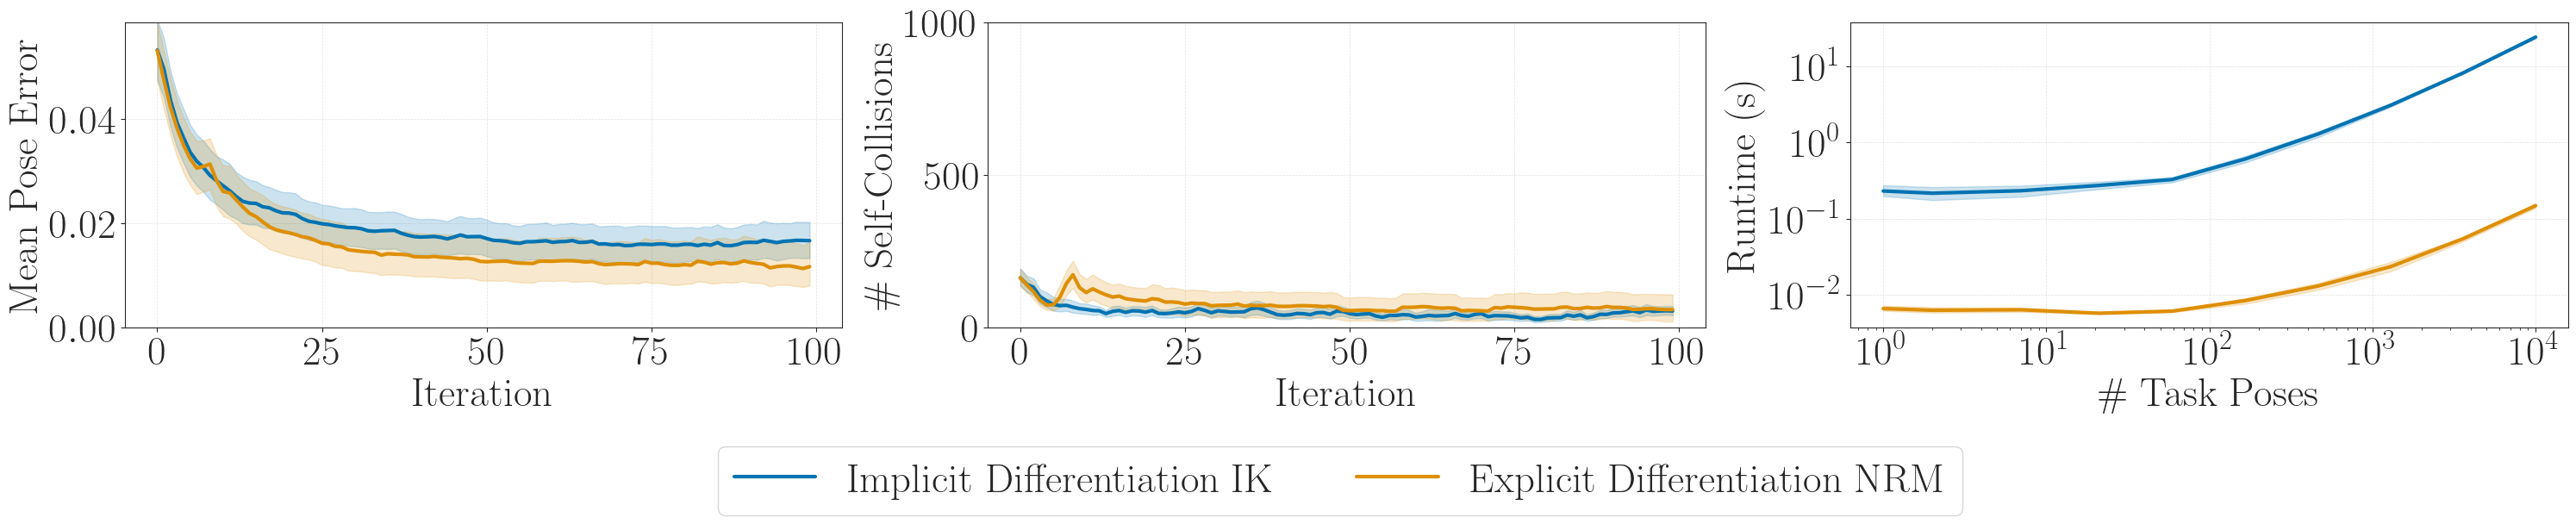

In [10]:
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})


fig, ax = plt.subplots(1, 3, figsize=(30, 5))
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)
ax[0].plot(x, mean_pose_error_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[0].fill_between(x, lower_pose_error_base, upper_pose_error_base, color=colors[0], alpha=0.2)
ax[0].plot(x, mean_pose_error_ours, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
ax[0].fill_between(x, lower_pose_error_ours, upper_pose_error_ours, color=colors[1], alpha=0.2)
ax[0].set_ylabel(r"$\text{Mean Pose Error}$")
ax[0].set_xlabel(r"$\text{Iteration}$")
ax[0].set_ylim(0.0, mean_pose_error_base.max()*1.1)

ax[1].plot(x, mean_self_collisions_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[1].fill_between(x, lower_self_collisions_base, upper_self_collisions_base, color=colors[0], alpha=0.2)
ax[1].plot(x, mean_self_collisions_ours, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
ax[1].fill_between(x, lower_self_collisions_ours, upper_self_collisions_ours, color=colors[1], alpha=0.2)
ax[1].set_ylim(-0.1, 1000 + 0.1)
ax[1].set_ylabel(r"$\text{\# Self-Collisions}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

x = torch.logspace(0, 4, 10).int()
per_iteration = 100
ax[2].plot(x, mean_base_runtime/per_iteration, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[2].fill_between(x, lower_base_runtime/per_iteration, upper_base_runtime/per_iteration, color=colors[0], alpha=0.2)
ax[2].plot(x, mean_ours_runtime/per_iteration, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
ax[2].fill_between(x, lower_ours_runtime/per_iteration, upper_ours_runtime/per_iteration, color=colors[1], alpha=0.2)
ax[2].set_ylabel(r"$\text{Runtime (s)}$")
ax[2].set_xlabel(r"$\text{\# Task Poses}$")
ax[2].set_yscale("log")
ax[2].set_xscale("log")
ax[2].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
ax[2].yaxis.set_minor_formatter(ticker.LogFormatterExponent())

for i in range(len(ax)):
    ax[i].grid(True, linestyle='--', alpha=0.6)

handles, labels = ax[0].get_legend_handles_labels()

# Add the legend to the FIGURE, not the AXES
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.52, 0.0)
)

plt.tight_layout()
plt.savefig("design_optimisation.pdf", format="pdf", bbox_inches="tight")
plt.show()